
# K-Means Clustering with and without Scaling

## Objective
Understand the impact of feature scaling on K-Means clustering.

## Dataset
`kmeans_scaling.csv`

## Tasks
- Apply K-Means:
  - Without scaling
  - With Standardization
- Compare clustering results

## Questions
1. How do cluster assignments differ before and after scaling?
2. Which feature dominates before scaling? Why?
3. Why is scaling important for distance-based algorithms?


In [3]:

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully")


Libraries imported successfully


In [4]:

# Load dataset

data = pd.read_csv("kmeans_scaling.csv")

print("First 5 rows of dataset:")
display(data.head())

print("\nDataset shape:", data.shape)


First 5 rows of dataset:


,Feature1,Feature2
0,0.496714,-82.899501
1,-0.138264,-56.018104
2,0.647689,74.729361
3,1.523030,61.037027
4,-0.234153,-2.090159



Dataset shape: (300, 2)


In [5]:

# Check dataset information

print("Dataset Information")
print(data.info())

print("\nStatistical Summary")
display(data.describe())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB
None

Statistical Summary


,Feature1,Feature2
count,300.000000,300.000000
mean,-0.005549,-2.148998
std,0.984194,96.161785
min,-3.241267,-247.164450
25%,-0.683246,-70.440519
50%,0.059219,-1.876467
75%,0.626658,61.633751
max,3.852731,307.888081



## Step 1: Select Features
We assume all columns are numerical features for clustering.


In [7]:

# Select features

X = data.copy()

print("Feature matrix shape:", X.shape)
display(X.head())


Feature matrix shape: (300, 2)


,Feature1,Feature2
0,0.496714,-82.899501
1,-0.138264,-56.018104
2,0.647689,74.729361
3,1.523030,61.037027
4,-0.234153,-2.090159



# K-Means WITHOUT Scaling


In [8]:

# Apply K-Means without scaling

kmeans_without_scaling = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_without_scaling = kmeans_without_scaling.fit_predict(X)

# Add cluster labels
data["Cluster_Without_Scaling"] = clusters_without_scaling

print("Cluster labels without scaling:")
print(clusters_without_scaling[:20])


Cluster labels without scaling:
[1 1 0 0 0 0 2 1 0 0 0 2 2 2 2 0 0 0 0 0]


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [9]:

# Centroids without scaling

print("Centroids without scaling:")
centroids_without = pd.DataFrame(
    kmeans_without_scaling.cluster_centers_,
    columns=X.columns
)

display(centroids_without)


Centroids without scaling:


,Feature1,Feature2
0,0.046587,19.842074
1,-0.001839,-98.743999
2,-0.128731,137.133532



# Standardization (Feature Scaling)

StandardScaler transforms data so that:
- Mean = 0
- Standard deviation = 1

Formula:

z = (x - mean) / std


In [10]:

# Apply standardization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

print("\nFirst 5 rows after scaling:")
print(X_scaled[:5])


Scaled data shape: (300, 2)

First 5 rows after scaling:
[[ 5.11181814e-01 -8.41138965e-01]
 [-1.35072487e-01 -5.61128442e-01]
 [ 6.64837178e-01  8.00804712e-01]
 [ 1.55572267e+00  6.58178286e-01]
 [-2.32664344e-01  6.12896104e-04]]



# K-Means WITH Scaling


In [11]:

# Apply K-Means on scaled data

kmeans_with_scaling = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_with_scaling = kmeans_with_scaling.fit_predict(X_scaled)

# Add cluster labels
data["Cluster_With_Scaling"] = clusters_with_scaling

print("Cluster labels with scaling:")
print(clusters_with_scaling[:20])


Cluster labels with scaling:
[0 2 0 0 2 1 0 0 1 0 2 1 1 1 1 2 1 0 1 2]


C:\Users\HP\anaconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [12]:

# Compare cluster assignments

comparison = data[[
    "Cluster_Without_Scaling",
    "Cluster_With_Scaling"
]]

display(comparison.head(20))


,Cluster_Without_Scaling,Cluster_With_Scaling
0,1,0
1,1,2
2,0,0
3,0,0
4,0,2
5,0,1
6,2,0
7,1,0
8,0,1
9,0,0



# Visual Comparison of Clusters


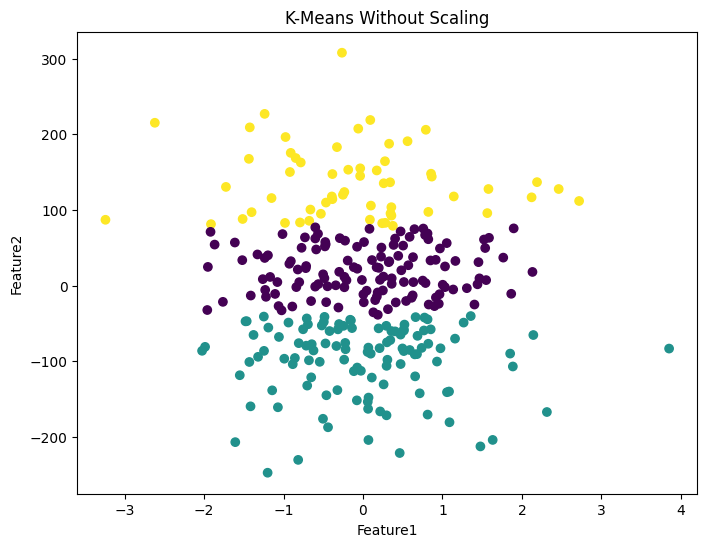

In [13]:

# Plot clusters before scaling

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=clusters_without_scaling
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-Means Without Scaling")

plt.show()


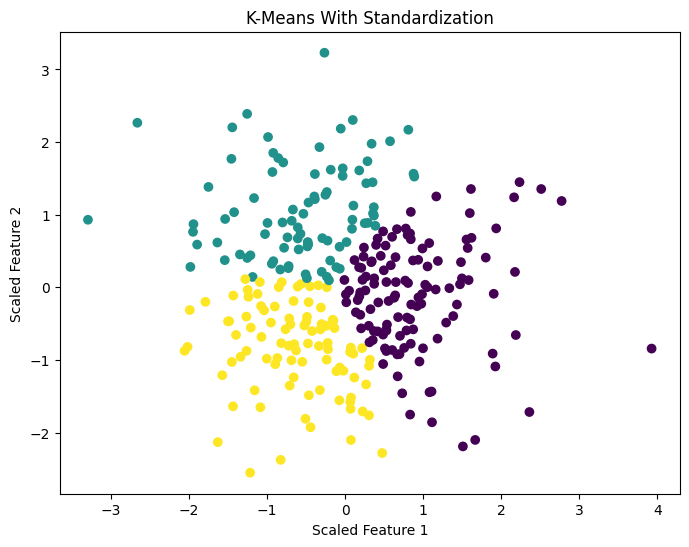

In [14]:

# Plot clusters after scaling

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters_with_scaling
)

plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.title("K-Means With Standardization")

plt.show()



# Understanding Feature Dominance

K-Means uses Euclidean distance.

If one feature has very large values compared to other features,
that feature dominates distance calculations.

Example:
- Salary: values in lakhs
- Age: values between 20–50

Salary will heavily influence clustering unless scaling is applied.


In [15]:

# Compare feature ranges

feature_ranges = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max(),
    "Range": X.max() - X.min()
})

display(feature_ranges)


,Minimum,Maximum,Range
Feature1,-3.241267,3.852731,7.093999
Feature2,-247.164450,307.888081,555.052531



# Answers to Questions

## 1. How do cluster assignments differ before and after scaling?
- Cluster assignments may change significantly.
- Without scaling, features with larger values dominate clustering.
- After scaling, all features contribute equally.

---

## 2. Which feature dominates before scaling? Why?
- The feature with the largest numerical range dominates.
- This happens because Euclidean distance becomes heavily influenced by larger values.

---

## 3. Why is scaling important for distance-based algorithms?
- Distance-based algorithms rely on numerical distance calculations.
- Features with larger magnitudes can bias results.
- Scaling ensures fair contribution from all features.
- It improves clustering quality and model reliability.
